# Control samples for the Gaia PMAs

In [1]:
import numpy as np
import pandas as pd
import os, sys #, glob
from dotmap import DotMap

In [2]:
#!pip install astroquery

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['axes.formatter.min_exponent'] = 3

In [4]:
sys.path.append('/Users/mulders/Work/Surveys/')
from tess_catalogs import astroquery_TOIs, CTL

In [5]:
#from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
#NasaExoplanetArchive.TAP_TABLES
#TOI= NasaExoplanetArchive.query_criteria(table='toi')

In [6]:
#for bugfixing, add %autoreload at top of of cell to trigger
# note: autoreload occasionally fs up working dir 
%load_ext autoreload
%autoreload 1 
# reload automatically, does not work?
%aimport histogram_sample_2d
#Samples= histogram_sample_2d.Samples

In [7]:
%autoreload 
ctl= CTL(Gaia=True, DropNaN=True, date= '2025April29')

Read from file: CTL_2025April29.npz


In [8]:
ctl.keys()

odict_keys(['Rst', 'Teff', 'Mst', 'Lst', 'd', 'Tmag', 'tic', 'gaia'])

## Load the table from Kervella paper

based on /Gaia/Proper Motion Anomaly/Gaia PMA.ipynb

In [9]:
from astropy.table import Table

In [10]:
fpath= '../Gaia/Proper Motion Anomaly/'
t = Table.read(fpath+'tablea1.dat',readme=fpath+'ReadMe.txt',format="ascii.cds")

In [11]:
isPMA2 = t['snrPMaHG1'] > 2
isPMA3 = t['snrPMaHG1'] > 3
isPMA5 = t['snrPMaHG1'] > 5

isPMA2.sum(),isPMA3.sum(),isPMA5.sum()

(30323, 20702, 15715)

In [12]:
isPlanet= t['M25au'] <= 20
isPlanet.sum()

52626

In [13]:
nz= t['M25au']> 0.1 # not zero but unrealistically low

In [14]:
(isPMA2 & isPlanet & nz).sum()

3967

In [15]:
from collections import OrderedDict

In [16]:
def data_dump(fname, t, PMAcut):
    tosave= nz&PMAcut&isPlanet
    print('Saving {} PMAs to {}'.format(
        tosave.sum(), fname))
    
    d=OrderedDict({})

    d['name']= t['Name'][tosave]
    d['hipparcos']= t['HIP'][tosave]
    d['gaia_dr2']= t['GaiaDR2'][tosave]
    d['gaia_dr3']= t['GaiaEDR3'][tosave]

    d['Mstar']= t['M1'][tosave]
    d['Rstar']= t['R1'][tosave]
    d['Mplanet']= t['M25au'][tosave]
    d['snrPMA']= t['snrPMaHG1'][tosave]
    d['Gmag']= t['Gmag'][tosave]

    df = pd.DataFrame(data=d)
    df.to_csv(fname)
    
    return df

In [17]:
df_pma= data_dump('PMA_2sigma.csv', t, isPMA2)

Saving 3967 PMAs to PMA_2sigma.csv


## Xmatch the TIC IDs from the CTL

Very similar cut to excluding evolved stars (606) to 3364

In [18]:
np.isin(df_pma['gaia_dr2'], ctl.gaia).sum()

3342

In [19]:
ctl.keys()

odict_keys(['Rst', 'Teff', 'Mst', 'Lst', 'd', 'Tmag', 'tic', 'gaia'])

In [20]:
for key in ctl.keys():
    print(key, type(ctl[key]))

Rst <class 'numpy.ndarray'>
Teff <class 'numpy.ndarray'>
Mst <class 'numpy.ndarray'>
Lst <class 'numpy.ndarray'>
d <class 'numpy.ndarray'>
Tmag <class 'numpy.ndarray'>
tic <class 'numpy.ndarray'>
gaia <class 'numpy.ndarray'>


In [21]:
#df_ctl= pd.DataFrame(ctl) # crashes on laptop
#df_ctl= pd.DataFrame(dict(ctl), columns=list(ctl.keys())) # nope
df_ctl= pd.DataFrame({key:ctl[key] for key in ctl.keys()}) # FU pandas

In [22]:
df= pd.merge(df_pma, df_ctl, left_on='gaia_dr2', right_on='gaia')
df.rename(columns={'ID': 'TIC', 
                    'Mst': 'Mstar_CTL', 
                    'Rst': 'Rstar_CTL',
                   }, inplace=True)
df.drop(columns=['gaia'], inplace=True)
#df.dropna(inplace=True)
print ('\nNaNs: ')
print (df.isna().sum())
df.to_csv('PMA_CTL_Xmatch.csv')


NaNs: 
name         0
hipparcos    0
gaia_dr2     0
gaia_dr3     0
Mstar        0
Rstar        0
Mplanet      0
snrPMA       0
Gmag         0
Rstar_CTL    0
Teff         0
Mstar_CTL    8
Lst          8
d            0
Tmag         0
tic          0
dtype: int64


In [23]:
df

,name,hipparcos,gaia_dr2,gaia_dr3,Mstar,Rstar,Mplanet,snrPMA,Gmag,Rstar_CTL,Teff,Mstar_CTL,Lst,d,Tmag,tic
0,HD 224743,33,2422810915898660096,2422810915898660096,1.50,1.92,8.82,2.17,8.0153,1.893650,6616.6099,1.385,6.192057,114.145000,7.67466,176218128
1,HD 224842,90,4995978049734140672,4995978049734140672,1.64,2.51,10.46,2.69,7.5445,2.461890,6393.0000,1.280,9.121141,111.686000,7.18020,369579212
2,HD 225028,223,2739059700184753280,2739059700184753280,1.13,1.48,11.63,3.30,7.2214,1.366720,5743.0000,1.030,1.830672,43.051800,6.75990,611064061
3,HD 225036,228,2854868408079958272,2854868408079958272,1.54,2.25,9.75,2.31,7.5326,2.207060,6248.0000,1.210,6.687844,95.978302,7.14980,118005686
4,BD+31 5024,249,2873571753703279360,2873571753703279360,1.16,1.14,6.39,2.13,8.6359,1.119680,6088.0000,1.140,1.551602,76.793800,8.23240,407336126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337,HD 224470,118170,6523625142997245184,6523625142997245184,1.40,1.56,5.12,2.14,8.1507,1.573040,6404.0000,1.290,3.749577,95.710403,7.79410,201233470
3338,HD 224508,118193,2851518986423871872,2851518986423871872,1.16,1.16,5.35,2.19,8.2552,1.150930,5916.0000,1.080,1.461851,62.316002,7.82400,239548596
3339,G 131-6,118196,2848490622163278464,2848490622163278464,0.60,0.83,17.12,2.55,11.0669,0.856018,4053.0000,0.630,0.178142,62.543701,10.24220,239548642
3340,HD 224611,118259,1945461889773383168,1945461889773383168,1.90,1.70,6.89,2.10,7.0698,1.743320,8117.0000,1.980,11.885878,99.849899,6.94270,403147494


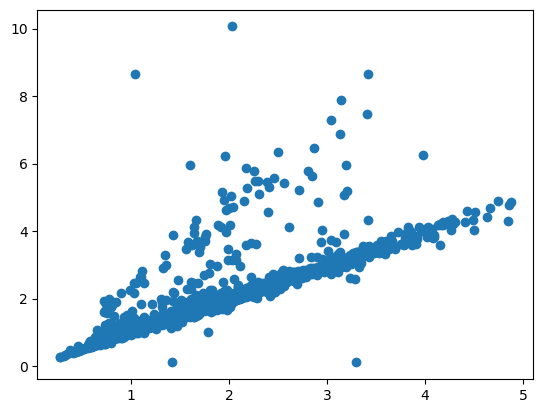

In [24]:
plt.scatter(df['Rstar_CTL'], df['Rstar'])

In [25]:
np.nanmedian(df['Rstar_CTL']/df['Rstar'])

0.9918667957602934

In [26]:
np.median(df['Rstar']), np.median(df['Mstar'])

(1.67, 1.4049999999999998)

In [27]:
#pma= DotMap()
#pma.

## Crossmatch the TIC

In [28]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
TOI= NasaExoplanetArchive.query_criteria(table='toi')

In [29]:
tic= TOI['tid'].filled().value

In [30]:
isTOI= np.isin(df['tic'], tic)

In [31]:
toiPMA= df['tic'][isTOI].to_numpy()

In [32]:
toiPMA

array([207084429, 120896927, 207141131,  98796344, 261136679, 350618622,
       177258735, 167656187,  19451711,  30828562,  91987762, 286132427,
       344927749,  61109252,  21535395,  20375215, 166053959, 232540264,
       160039081, 305943739,  16740101, 375506058, 372264750, 410214986])

In [33]:
df_toi= TOI.to_pandas()

In [34]:
df_toi

,tid,toi,toidisplay,toipfx,ctoi_alias,pl_pnum,tfopwg_disp,st_tmag,st_tmagerr1,st_tmagerr2,...,st_raderr1,st_raderr2,st_radsymerr,st_radlim,sectors,toi_created,rowupdate,release_date,sky_coord.ra,sky_coord.dec
0,16288184,1049.01,TOI-1049.01,1049,16288184.01,1,KP,11.06570,0.006,-0.006,...,0.063558,-0.063558,1,0,,2019-07-15 19:20:04,2022-03-30 16:02:02,2025-04-21 11:53:15,253.768848,-28.710584
1,144065872,105.01,TOI-105.01,105,144065872.01,1,KP,9.49950,0.006,-0.006,...,0.059699,-0.059699,1,0,,2018-09-05 18:49:20,2025-03-25 16:00:01,2025-04-21 11:53:15,337.457824,-48.003099
2,66818296,1050.01,TOI-1050.01,1050,66818296.01,1,KP,11.02610,0.006,-0.006,...,0.090000,-0.090000,1,0,,2019-07-15 19:20:05,2022-10-05 10:10:01,2025-04-21 11:53:15,239.962248,-28.061794
3,259863352,1051.01,TOI-1051.01,1051,259863352.01,1,FA,7.12780,0.006,-0.006,...,0.186629,-0.186629,1,0,,2019-08-16 20:20:45,2024-09-17 10:08:02,2025-04-21 11:53:15,40.365939,-71.462749
4,317060587,1052.01,TOI-1052.01,1052,317060587.01,1,CP,9.01970,0.006,-0.006,...,0.165123,-0.165123,1,0,,2019-08-16 20:20:47,2023-07-24 12:03:31,2025-04-21 11:53:15,337.510274,-75.646561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7571,306996324,776.02,TOI-776.02,776,306996324.02,2,CP,9.73597,0.007,-0.007,...,0.015777,-0.015777,1,0,,2019-06-11 20:03:40,2024-10-03 10:08:02,2025-04-21 11:53:15,178.577997,-37.553357
7572,334305570,777.01,TOI-777.01,777,334305570.01,1,PC,9.37120,0.006,-0.006,...,0.083312,-0.083312,1,0,,2019-06-11 20:03:40,2024-09-19 10:08:01,2025-04-21 11:53:15,183.118731,-49.007740
7573,335630746,778.01,TOI-778.01,778,335630746.01,1,CP,8.69009,0.006,-0.006,...,0.070000,-0.070000,1,0,,2019-06-11 20:03:40,2024-09-10 10:08:02,2025-04-21 11:53:15,199.333850,-15.273705
7574,374095457,779.01,TOI-779.01,779,374095457.01,1,PC,8.21580,0.007,-0.007,...,NaN,NaN,1,0,,2019-06-05 19:57:35,2024-09-01 12:02:56,2025-04-21 11:53:15,159.933006,-48.996687


In [35]:
np.unique(df_toi['tfopwg_disp'])

array(['', 'APC', 'CP', 'FA', 'FP', 'KP', 'PC'], dtype=object)

In [36]:
df_toi= df_toi[df_toi['tfopwg_disp'].isin(['APC', 'CP', 'KP', 'PC'])]

In [37]:
itoi= df_toi['tid'].isin(toiPMA)
#iPC= df_toi['tfopwg_disp'].isin(['APC', 'CP', 'KP', 'PC'])
itoi.sum() #, (itoi&iPC).sum()
df_toi[itoi].columns

Index(['tid', 'toi', 'toidisplay', 'toipfx', 'ctoi_alias', 'pl_pnum',
       'tfopwg_disp', 'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmagsymerr',
       'st_tmaglim', 'rastr', 'ra', 'raerr1', 'raerr2', 'rasymerr', 'decstr',
       'dec', 'decerr1', 'decerr2', 'decsymerr', 'st_pmra', 'st_pmraerr1',
       'st_pmraerr2', 'st_pmrasymerr', 'st_pmralim', 'st_pmdec',
       'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdecsymerr', 'st_pmdeclim',
       'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidsymerr',
       'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2',
       'pl_orbpersymerr', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1',
       'pl_trandurherr2', 'pl_trandurhsymerr', 'pl_trandurhlim', 'pl_trandep',
       'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandepsymerr', 'pl_trandeplim',
       'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radesymerr', 'pl_radelim',
       'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insolsymerr',
       'pl_insollim', 'pl_eqt

In [38]:
df_toi[itoi][['tid','pl_orbper','pl_rade']]

,tid,pl_orbper,pl_rade
173,16740101,1.481090,20.340242
292,232540264,15.923488,2.182030
423,372264750,2.170272,15.259059
526,375506058,2.650232,15.932700
536,261136679,6.267832,1.997790
920,21535395,2.800991,1.403391
940,207141131,4.137438,2.675766
1466,410214986,8.138222,6.175768
1478,350618622,52.978142,11.447149
1479,350618622,5.849238,1.189190


Text(0, 0.5, 'Radius [Earth]')

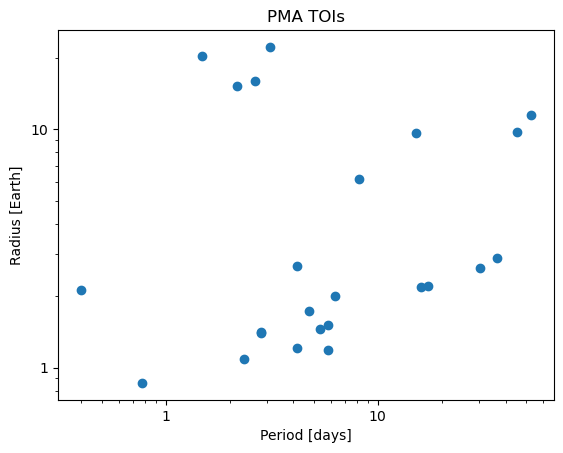

In [39]:
plt.loglog()
plt.scatter(df_toi[itoi]['pl_orbper'],df_toi[itoi]['pl_rade'])
plt.title('PMA TOIs')
plt.xlabel('Period [days]')
plt.ylabel('Radius [Earth]')

In [40]:
df_toi[itoi][['tid','toi','pl_orbper','pl_rade']]

,tid,toi,pl_orbper,pl_rade
173,16740101,1150.01,1.481090,20.340242
292,232540264,1247.01,15.923488,2.182030
423,372264750,1355.01,2.170272,15.259059
526,375506058,1431.01,2.650232,15.932700
536,261136679,144.01,6.267832,1.997790
920,21535395,1776.01,2.800991,1.403391
940,207141131,179.01,4.137438,2.675766
1466,410214986,200.01,8.138222,6.175768
1478,350618622,201.01,52.978142,11.447149
1479,350618622,201.02,5.849238,1.189190


## Draw the control sample

In [41]:
cat= histogram_sample_2d.Samples('PMA CTL')
cat.xlabel= 'Rst [Rsun]'
cat.ylabel= 'Magnitude'
cat.zlabel= 'Teff [K]'

In [42]:
cat.set_parent('CTL', ctl.Rst, ctl.Tmag, extra= ctl.Teff, ID=ctl.tic)

In [43]:
cat.set_target('PMA', df['Rstar'], df['Tmag'], extra= df['Teff'], ID=df['tic'])

In [44]:
cat.set_xbins(0.1,10,21)
cat.set_ybins(4,12,20, Log=False)
cat.set_zbins(2000,12000,21, Log=False)

3341/3342,  left: 0, right: 1
9194571/9194582,  left: 10, right: 1
KstestResult(statistic=0.3923613789004192, pvalue=0.0, statistic_location=0.76999998, statistic_sign=1)


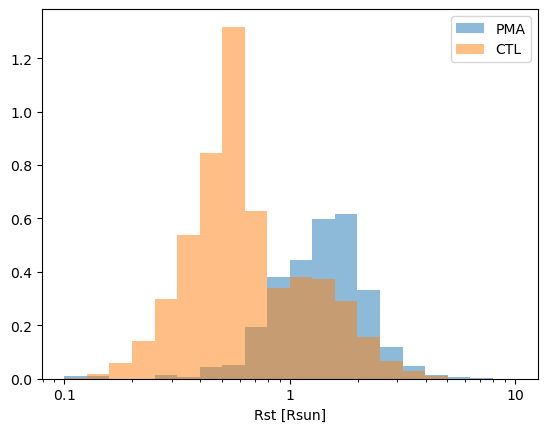

In [ ]:
cat.plothist_x() # showing samples of Gaia stars vs CTL

3341/3342,  under: 0, over: 1
2139806/9194582,  under: 98, over: 7054678
KstestResult(statistic=0.9665156455476818, pvalue=0.0, statistic_location=9.8499298, statistic_sign=-1)


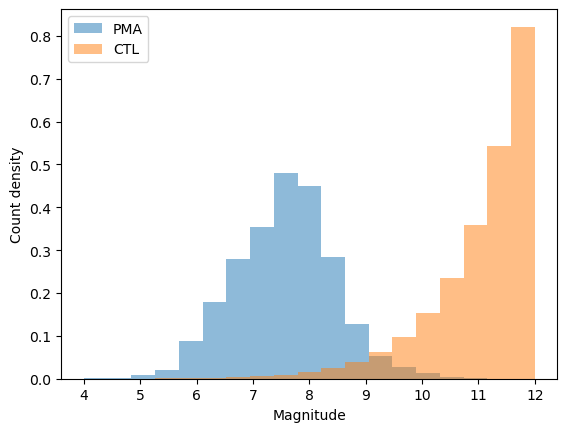

In [46]:
cat.plothist_y()

before: KstestResult(statistic=0.3830693321345559, pvalue=0.0, statistic_location=4041.99, statistic_sign=1)


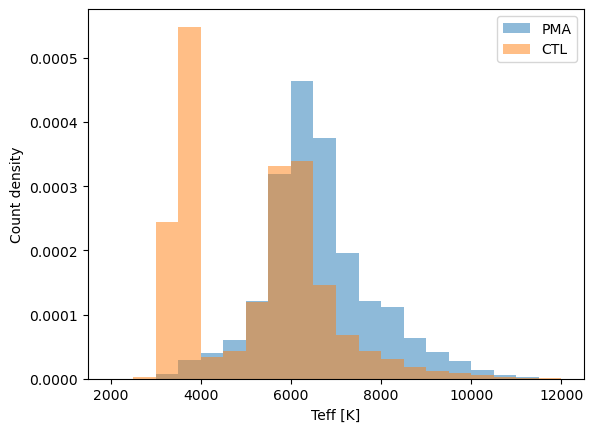

In [47]:
cat.plothist_z()

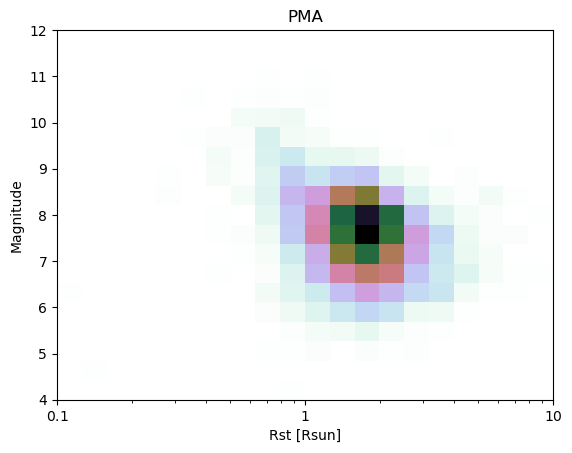

In [48]:
cat.hist2d_target()

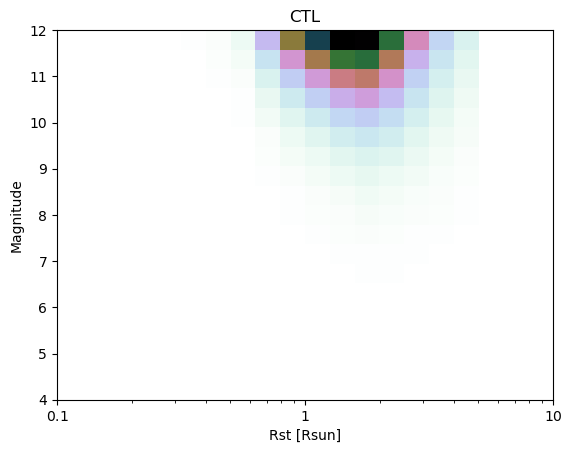

In [49]:
cat.hist2d_parent()

7/380 are undersampled


/Users/mulders/Work/Sample/histogram_sample_2d.py:243: RuntimeWarning: divide by zero encountered in divide
  ratio2d= 1.0/scale * self.target.h2d / self.parent.h2d
/Users/mulders/Work/Sample/histogram_sample_2d.py:243: RuntimeWarning: invalid value encountered in divide
  ratio2d= 1.0/scale * self.target.h2d / self.parent.h2d


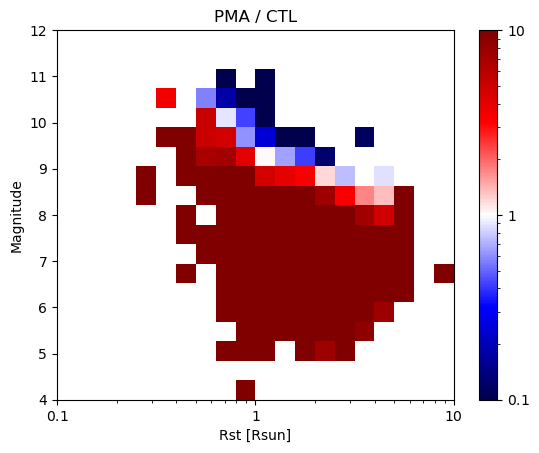

In [50]:
cat.hist2d_compare()

In [51]:
%autoreload
cat.make_control(ID=True)

missing 0/3342
trimming parent sample 9191240/9194582

9/380 cells are undersampled


/Users/mulders/Work/Sample/histogram_sample_2d.py:329: RuntimeWarning: invalid value encountered in scalar divide
  self.parent.draw_prob[indices_to_draw_from]= n_target/TF_parent.sum()


  Nothing to sample at i=1,j=6, want n=1
  Nothing to sample at i=2,j=2, want n=1
  Nothing to sample at i=7,j=7, want n=1
Draw with replacement 9,5
  Nothing to sample at i=19,j=6, want n=1
  Nothing to sample at i=19,j=7, want n=1
  Nothing to sample at i=19,j=9, want n=3
  Nothing to sample at i=19,j=11, want n=1
  Nothing to sample at i=20,j=10, want n=1

summed weights parent sample: n=3329.9999999999995

control sample n=3330


8/380 are off


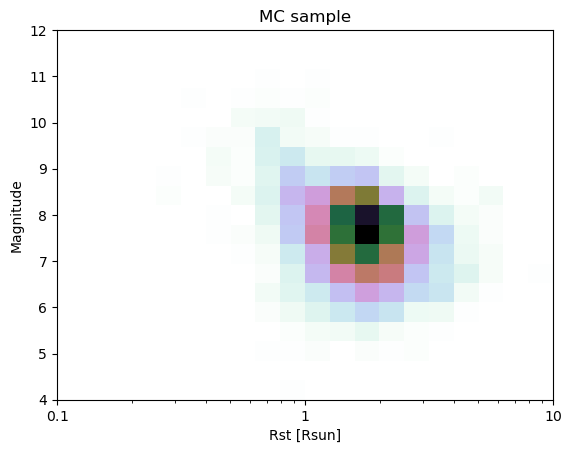

In [52]:
cat.hist2d_draw()

In [53]:
cat.verify_control()

xvar: 
 distance: 0.066 -> 0.021
 probability: 3.93e-13 -> 0.47

yvar: 
 distance: 0.917 -> 0.027
 probability: 0 -> 0.177

zvar: 
 distance: 0.139 -> 0.058
 probability: 5.71e-57 -> 2.68e-05


after: KstestResult(statistic=0.0578437719156282, pvalue=2.682169935098369e-05, statistic_location=8670.0, statistic_sign=-1)


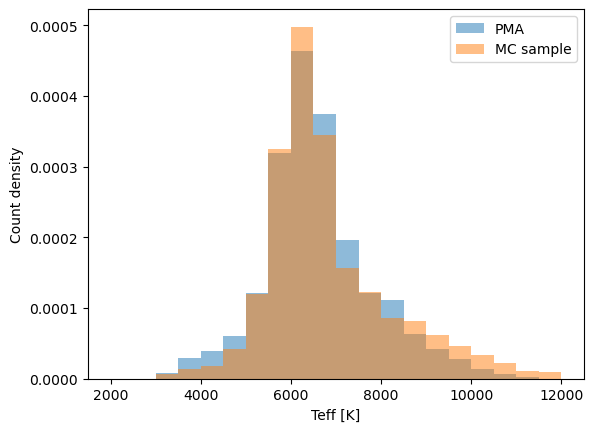

In [54]:
cat.plothist_z(Draw=True, Parent=False)

In [55]:
cat.parent.h2d.sum()

2140043.0

In [56]:
cat.target.h2d.sum()

3340.0

Xmatch control sample back to TOI list

In [57]:
idraw= df_toi['tid'].isin(cat.draw.ID)
idraw.sum()

18

(0.3, 100)

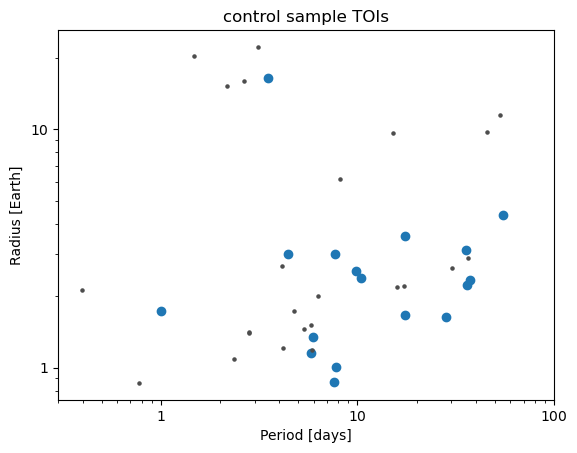

In [58]:
plt.loglog()
plt.scatter(df_toi[idraw]['pl_orbper'],df_toi[idraw]['pl_rade'])
plt.scatter(df_toi[itoi]['pl_orbper'],df_toi[itoi]['pl_rade'], color='0.3', s=5)
plt.title('control sample TOIs')
plt.xlabel('Period [days]')
plt.ylabel('Radius [Earth]')

plt.xlim(0.3,100)

In [77]:
def isHJ(P, Rp): return ((1<=P) & (P<=10) & (6<=Rp) & (Rp<=24))
def isGP(P, Rp): return ((1<=P) & (P<=28) & (4<=Rp) & (Rp<=24))
def isSE(P, Rp): return ((1<=P) & (P<=28) & (0.8<=Rp) & (Rp<=4.0))
def isMN(P, Rp): return ((1<=P) & (P<=14) & (1.5<=Rp) & (Rp<=4.0))

In [78]:
nHJ_pma= np.sum(isHJ(df_toi[itoi]['pl_orbper'], df_toi[itoi]['pl_rade']))
nHJ_draw= np.sum(isHJ(df_toi[idraw]['pl_orbper'], df_toi[idraw]['pl_rade']))

print (f'Hot Jupiters PMA: {nHJ_pma}, control: {nHJ_draw}')

Hot Jupiters PMA: 5, control: 1


In [79]:
nGP_pma= np.sum(isGP(df_toi[itoi]['pl_orbper'], df_toi[itoi]['pl_rade']))
nGP_draw= np.sum(isGP(df_toi[idraw]['pl_orbper'], df_toi[idraw]['pl_rade']))

print (f'Giant Planets PMA: {nGP_pma}, control: {nGP_draw}')

Giant Planets PMA: 6, control: 1


In [80]:
nSE_pma= np.sum(isSE(df_toi[itoi]['pl_orbper'], df_toi[itoi]['pl_rade']))
nSE_draw= np.sum(isSE(df_toi[idraw]['pl_orbper'], df_toi[idraw]['pl_rade']))

print (f'super Earths PMA: {nSE_pma}, control: {nSE_draw}')

super Earths PMA: 12, control: 11


In [81]:
nMN_pma= np.sum(isMN(df_toi[itoi]['pl_orbper'], df_toi[itoi]['pl_rade']))
nMN_draw= np.sum(isMN(df_toi[idraw]['pl_orbper'], df_toi[idraw]['pl_rade']))

print (f'mini Neptunes PMA: {nMN_pma}, control: {nMN_draw}')

mini Neptunes PMA: 4, control: 5


## Try the occurrence from the CTL with draw probability

In [82]:
i_nz= cat.parent.draw_prob >0
#i_nz.size, i_nz.sum()

tic_nz= cat.parent.ID[i_nz]
tic_prob= cat.parent.draw_prob[i_nz]
print (tic_prob.sum())

3330.0000000000005


In [65]:
df_prob= pd.DataFrame(data= dict(tic_nz=tic_nz, draw_prob= tic_prob) )

In [66]:
df_draw= pd.merge(df_toi, df_prob, left_on='tid', right_on='tic_nz')

In [67]:
df_draw['draw_prob'].sum()

20.33019937720626

In [68]:
df_draw

,tid,toi,toidisplay,toipfx,ctoi_alias,pl_pnum,tfopwg_disp,st_tmag,st_tmagerr1,st_tmagerr2,...,st_radsymerr,st_radlim,sectors,toi_created,rowupdate,release_date,sky_coord.ra,sky_coord.dec,tic_nz,draw_prob
0,144065872,105.01,TOI-105.01,105,144065872.01,1,KP,9.49950,0.006,-0.006,...,1,0,,2018-09-05 18:49:20,2025-03-25 16:00:01,2025-04-21 11:53:15,337.457824,-48.003099,144065872,0.000382
1,317060587,1052.01,TOI-1052.01,1052,317060587.01,1,CP,9.01970,0.006,-0.006,...,1,0,,2019-08-16 20:20:47,2023-07-24 12:03:31,2025-04-21 11:53:15,337.510274,-75.646561,317060587,0.006168
2,366989877,1054.01,TOI-1054.01,1054,366989877.01,1,CP,8.43620,0.006,-0.006,...,1,0,,2019-08-16 20:20:48,2023-09-14 16:02:01,2025-04-21 11:53:15,302.114174,-54.317501,366989877,0.028101
3,320004517,1055.01,TOI-1055.01,1055,320004517.01,1,CP,8.08880,0.006,-0.006,...,1,0,,2019-08-16 20:20:47,2024-10-01 10:08:01,2025-04-21 11:53:15,293.286615,-54.532728,320004517,0.060150
4,421894914,1056.01,TOI-1056.01,1056,421894914.01,1,PC,9.66630,0.006,-0.006,...,1,0,,2019-08-16 20:20:50,2024-03-14 16:54:32,2025-04-21 11:53:15,339.258703,-76.917605,421894914,0.000064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,67181830,6912.01,TOI-6912.01,6912,67181830.01,1,PC,8.56270,0.006,-0.006,...,1,0,,2024-02-15 23:14:21,2024-05-11 12:03:03,2025-04-21 11:53:15,83.145190,36.112303,67181830,0.026632
1274,306996324,776.01,TOI-776.01,776,306996324.01,1,CP,9.73597,0.007,-0.007,...,1,0,,2019-06-11 20:03:40,2024-10-03 10:08:02,2025-04-21 11:53:15,178.577997,-37.553357,306996324,0.008242
1275,306996324,776.02,TOI-776.02,776,306996324.02,2,CP,9.73597,0.007,-0.007,...,1,0,,2019-06-11 20:03:40,2024-10-03 10:08:02,2025-04-21 11:53:15,178.577997,-37.553357,306996324,0.008242
1276,334305570,777.01,TOI-777.01,777,334305570.01,1,PC,9.37120,0.006,-0.006,...,1,0,,2019-06-11 20:03:40,2024-09-19 10:08:01,2025-04-21 11:53:15,183.118731,-49.007740,334305570,0.000648


(0.3, 100)

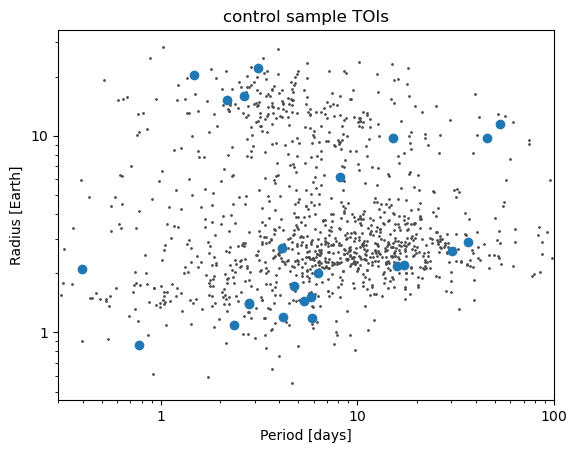

In [69]:
plt.loglog()
plt.scatter(df_draw['pl_orbper'],df_draw['pl_rade'], color='0.3', s=1)
plt.scatter(df_toi[itoi]['pl_orbper'],df_toi[itoi]['pl_rade'])
plt.title('control sample TOIs')
plt.xlabel('Period [days]')
plt.ylabel('Radius [Earth]')

plt.xlim(0.3,100)

In [83]:
nHJ_draw= df_draw['draw_prob'][isHJ(df_draw['pl_orbper'],df_draw['pl_rade'])].sum()

print (f'Hot Jupiters PMA: {nHJ_pma}, control: {nHJ_draw}')

Hot Jupiters PMA: 5, control: 1.7386479265172192


In [84]:
nGP_draw= df_draw['draw_prob'][isGP(df_draw['pl_orbper'],df_draw['pl_rade'])].sum()

print (f'Giant Planets PMA: {nGP_pma}, control: {nGP_draw}')

Giant Planets PMA: 6, control: 2.9869842261988335


In [85]:
nSE_draw= df_draw['draw_prob'][isSE(df_draw['pl_orbper'],df_draw['pl_rade'])].sum()

print (f'super Earths PMA: {nSE_pma}, control: {nSE_draw}')

super Earths PMA: 12, control: 11.999756765776365


In [86]:
nMN_draw= df_draw['draw_prob'][isMN(df_draw['pl_orbper'],df_draw['pl_rade'])].sum()

print (f'mini Neptunes PMA: {nMN_pma}, control: {nMN_draw}')

mini Neptunes PMA: 4, control: 6.906362853288893


hmm

In [88]:
# MN out: -6 -> still half :)
# snr: 207141131, 20375215, 344927749 (2x)
# 350618622(wrong planet), 
# 98796344(var), 
df_toi[itoi][isSE(df_toi[itoi]['pl_orbper'], df_toi[itoi]['pl_rade'])]

,tid,toi,toidisplay,toipfx,ctoi_alias,pl_pnum,tfopwg_disp,st_tmag,st_tmagerr1,st_tmagerr2,...,st_raderr1,st_raderr2,st_radsymerr,st_radlim,sectors,toi_created,rowupdate,release_date,sky_coord.ra,sky_coord.dec
292,232540264,1247.01,TOI-1247.01,1247,232540264.01,1,CP,8.47240,0.006,-0.006,...,0.050000,-0.050000,1,0,,2019-10-17 00:30:12,2025-04-20 12:03:53,2025-04-21 11:53:15,227.867864,71.841296
536,261136679,144.01,TOI-144.01,144,261136679.01,1,CP,5.10540,0.006,-0.006,...,0.050000,-0.050000,1,0,,2019-05-07 17:42:40,2023-04-04 16:02:02,2025-04-21 11:53:15,84.299280,-80.464604
920,21535395,1776.01,TOI-1776.01,1776,21535395.01,1,CP,7.65860,0.006,-0.006,...,0.038776,-0.038776,1,0,,2020-03-12 15:35:29,2021-10-29 12:59:15,2025-04-21 11:53:15,164.777291,40.983718
940,207141131,179.01,TOI-179.01,179,207141131.01,1,CP,8.17960,0.006,-0.006,...,0.047962,-0.047962,1,0,,2018-12-20 17:24:11,2024-09-10 10:08:02,2025-04-21 11:53:15,44.262014,-56.191869
1479,350618622,201.02,TOI-201.02,201,350618622.02,2,PC,8.58220,0.006,-0.006,...,0.060000,-0.060000,1,0,,2020-03-11 15:13:21,2023-11-15 16:02:02,2025-04-21 11:53:15,87.401782,-54.910423
3702,120896927,402.01,TOI-402.01,402,120896927.01,1,CP,8.31570,0.006,-0.006,...,0.041842,-0.041842,1,0,,2019-01-31 17:54:46,2024-09-10 10:08:02,2025-04-21 11:53:15,36.867885,-27.636117
3703,120896927,402.02,TOI-402.02,402,120896927.02,2,CP,8.31570,0.006,-0.006,...,0.041842,-0.041842,1,0,,2019-01-31 17:54:46,2024-09-10 10:08:02,2025-04-21 11:53:15,36.867885,-27.636117
3950,98796344,455.01,TOI-455.01,455,98796344.01,1,CP,8.84294,0.008,-0.008,...,0.008283,-0.008283,1,0,,2019-02-08 19:54:07,2021-12-02 16:02:01,2025-04-21 11:53:15,45.462478,-16.594496
5347,166053959,5383.01,TOI-5383.01,5383,166053959.01,1,PC,7.90653,0.006,-0.006,...,0.060000,-0.060000,1,0,,2022-03-24 21:34:46,2024-04-26 12:02:55,2025-04-21 11:53:15,212.720875,62.522196
5730,20375215,6709.01,TOI-6709.01,6709,20375215.01,1,PC,8.83920,0.006,-0.006,...,0.052372,-0.052372,1,0,,2023-10-05 21:59:27,2024-01-23 12:02:45,2025-04-21 11:53:15,167.608218,-29.414302
